In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df=pd.read_csv("predictive_maintenance_v3.csv")

In [37]:
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.shape

(24042, 15)

In [40]:
df.columns

Index(['timestamp', 'machine_id', 'machine_type', 'vibration_rms',
       'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm',
       'operating_mode', 'hours_since_maintenance', 'ambient_temp',
       'rul_hours', 'failure_within_24h', 'failure_type',
       'estimated_repair_cost'],
      dtype='object')

In [41]:
df.columns=df.columns.str.strip()

In [42]:
df.drop(columns=['rul_hours','failure_type','estimated_repair_cost','timestamp'],inplace=True)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   machine_id               24042 non-null  int64  
 1   machine_type             24042 non-null  object 
 2   vibration_rms            23042 non-null  float64
 3   temperature_motor        23208 non-null  float64
 4   current_phase_avg        23311 non-null  float64
 5   pressure_level           23118 non-null  float64
 6   rpm                      23509 non-null  float64
 7   operating_mode           24042 non-null  object 
 8   hours_since_maintenance  24042 non-null  float64
 9   ambient_temp             24042 non-null  float64
 10  failure_within_24h       24042 non-null  int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 2.0+ MB


In [44]:
df.isnull().sum().sort_values(ascending=False)

vibration_rms              1000
pressure_level              924
temperature_motor           834
current_phase_avg           731
rpm                         533
machine_type                  0
machine_id                    0
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
failure_within_24h            0
dtype: int64

In [45]:
df.describe()

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,failure_within_24h
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,0.148074
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,0.355181
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.000000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.000000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,0.000000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,0.000000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,1.000000


In [46]:
X=df.drop('failure_within_24h',axis=1)
Y=df['failure_within_24h']

In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
numeric_features = [
    'machine_id',
    'vibration_rms',
    'temperature_motor',
    'current_phase_avg',
    'pressure_level',
    'rpm',
    'hours_since_maintenance',
    'ambient_temp'
]

categorical_features = [
    'machine_type',
    'operating_mode'
]

numeric_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline([
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        drop='first'
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [49]:
from sklearn.linear_model import LogisticRegression

model_l = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

model_l.fit(X_train, Y_train)

y_pred_l = model_l.predict(X_test)

print('LogisticRegression')
print(classification_report(Y_test,y_pred_l))

LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      4097
           1       0.85      0.72      0.78       712

    accuracy                           0.94      4809
   macro avg       0.90      0.85      0.87      4809
weighted avg       0.94      0.94      0.94      4809



In [50]:
from sklearn.svm import SVC

model_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC())
])

model_svc.fit(X_train, Y_train)

y_pred_svc = model_svc.predict(X_test)

print('SVC')
print(classification_report(Y_test, y_pred_svc))

SVC
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      4097
           1       0.84      0.83      0.83       712

    accuracy                           0.95      4809
   macro avg       0.91      0.90      0.90      4809
weighted avg       0.95      0.95      0.95      4809



In [51]:
from sklearn.tree import DecisionTreeClassifier

model_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42
    ))
])

model_dt.fit(X_train, Y_train)

y_pred_dt = model_dt.predict(X_test)

print('Decision Tree')
print(classification_report(Y_test, y_pred_dt))

Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      4097
           1       0.84      0.87      0.86       712

    accuracy                           0.96      4809
   macro avg       0.91      0.92      0.92      4809
weighted avg       0.96      0.96      0.96      4809



In [52]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, Y_train)

y_pred_rf = model_rf.predict(X_test)

print('Random Forest')
print(classification_report(Y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4097
           1       0.92      0.91      0.92       712

    accuracy                           0.98      4809
   macro avg       0.95      0.95      0.95      4809
weighted avg       0.98      0.98      0.98      4809



In [53]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        random_state=42
    ))
])

model_gb.fit(X_train, Y_train)

y_pred_gb = model_gb.predict(X_test)

print('Gradient Boosting')
print(classification_report(Y_test, y_pred_gb))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      4097
           1       0.88      0.81      0.84       712

    accuracy                           0.95      4809
   macro avg       0.92      0.89      0.91      4809
weighted avg       0.95      0.95      0.95      4809



In [54]:
from xgboost import XGBClassifier

model_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss'
    ))
])

model_xgb.fit(X_train, Y_train)

y_pred_xgb = model_xgb.predict(X_test)

print('XGBoost')
print(classification_report(Y_test, y_pred_xgb))

XGBoost
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4097
           1       0.94      0.94      0.94       712

    accuracy                           0.98      4809
   macro avg       0.96      0.97      0.97      4809
weighted avg       0.98      0.98      0.98      4809



In [55]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

model_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, Y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.Se

In [56]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV F1:
0.9333119471466741


In [57]:
best_xgb = grid_search.best_estimator_

In [58]:
y_pred = best_xgb.predict(X_test)

print("Final XGBoost")
print(classification_report(Y_test, y_pred))

Final XGBoost
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4097
           1       0.94      0.95      0.94       712

    accuracy                           0.98      4809
   macro avg       0.97      0.97      0.97      4809
weighted avg       0.98      0.98      0.98      4809



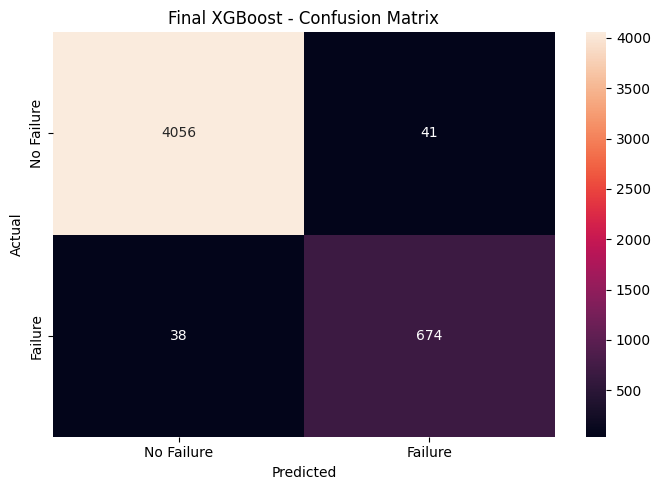

In [59]:
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No Failure', 'Failure'],
    yticklabels=['No Failure', 'Failure']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final XGBoost - Confusion Matrix')

plt.tight_layout()
plt.show()

In [60]:
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()

importances = best_xgb.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
12,cat__operating_mode_peak,0.332338
2,num__temperature_motor,0.146141
5,num__rpm,0.127998
11,cat__operating_mode_normal,0.109314
1,num__vibration_rms,0.075551
3,num__current_phase_avg,0.047869
9,cat__machine_type_Pump,0.044450
4,num__pressure_level,0.030839
0,num__machine_id,0.029916
6,num__hours_since_maintenance,0.024531


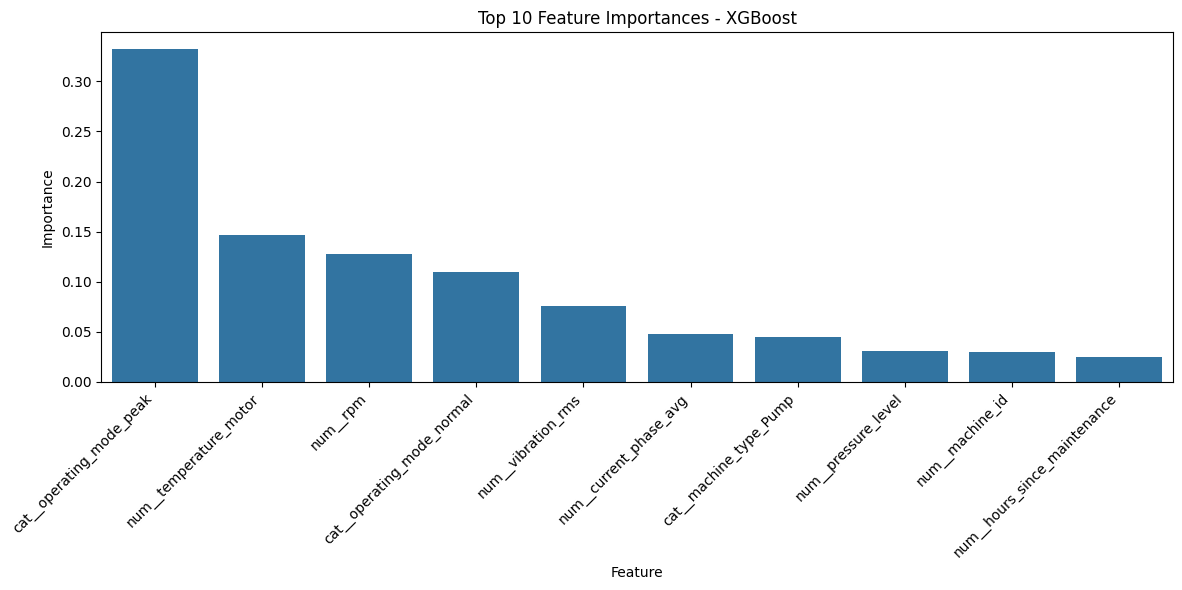

In [61]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Feature',
    y='Importance'
)

plt.title('Top 10 Feature Importances - XGBoost')
plt.xlabel('Feature')
plt.ylabel('Importance')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [62]:
import joblib

joblib.dump(best_xgb, "failure_24h_pipeline.pkl")

print("Failure 24h Pipeline saved successfully!")

Failure 24h Pipeline saved successfully!
